In [10]:
# INSTALL DEPENDENCIES

!pip install pandas matplotlib seaborn scikit-learn wordcloud

In [12]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

In [13]:
# Load Dataset

df = pd.read_csv("amazon_reviews.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [15]:
# Data Inspection

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nMissing Values Per Column:")
print(df.isnull().sum())

Dataset Shape: (1597, 27)

Column Names:
['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded', 'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer', 'manufacturerNumber', 'name', 'prices', 'reviews.date', 'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes', 'upc', 'weight']

First 5 Rows:


,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams



Missing Values Per Column:
id                         0
asins                      0
brand                      0
categories                 0
colors                   823
dateAdded                  0
dateUpdated                0
dimension               1032
ean                      699
keys                       0
manufacturer             632
manufacturerNumber       695
name                       0
prices                     0
reviews.date             380
reviews.doRecommend     1058
reviews.numHelpful       697
reviews.rating           420
reviews.sourceURLs         0
reviews.text               0
reviews.title             17
reviews.userCity        1597
reviews.userProvince    1597
reviews.username          17
sizes                   1597
upc                      699
weight                   911
dtype: int64


In [19]:
# Data Cleaning

df = df[[
    "name",
    "brand",
    "reviews.text"
]]

df.dropna(subset=["reviews.text"], inplace=True)
df.drop_duplicates(subset=["reviews.text"], inplace=True)

print("Shape After Cleaning:", df.shape)

Shape After Cleaning: (1048, 3)


In [20]:
# Review Text Extraction

reviews = df["reviews.text"]

print("Total Reviews for Analysis:", len(reviews))

Total Reviews for Analysis: 1048


In [24]:
# Feature Extraction Using Improved CountVectorizer

custom_stopwords = [
    'amazon', 'kindle', 'device', 'like',
    'just', 'good', 'great', 'use'
]

vectorizer = CountVectorizer(
    stop_words='english',
    max_features=50,
    ngram_range=(1,2),
    min_df=5
)

X = vectorizer.fit_transform(reviews)

words = vectorizer.get_feature_names_out()

# Remove custom irrelevant words manually
words_filtered = []
freq_filtered = []

frequencies = X.toarray().sum(axis=0)

for word, freq in zip(words, frequencies):
    if word not in custom_stopwords:
        words_filtered.append(word)
        freq_filtered.append(freq)

feature_df = pd.DataFrame({
    "Feature": words_filtered,
    "Frequency": freq_filtered
})

feature_df = feature_df.sort_values(
    by="Frequency",
    ascending=False
)

display(feature_df.head(15))

,Feature,Frequency
34,tv,425
31,tablet,354
11,echo,321
27,screen,319
32,tap,298
22,read,295
29,sound,291
15,new,290
33,time,285
13,love,274


C:\Users\kalya\AppData\Local\Temp\ipykernel_16516\801729008.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


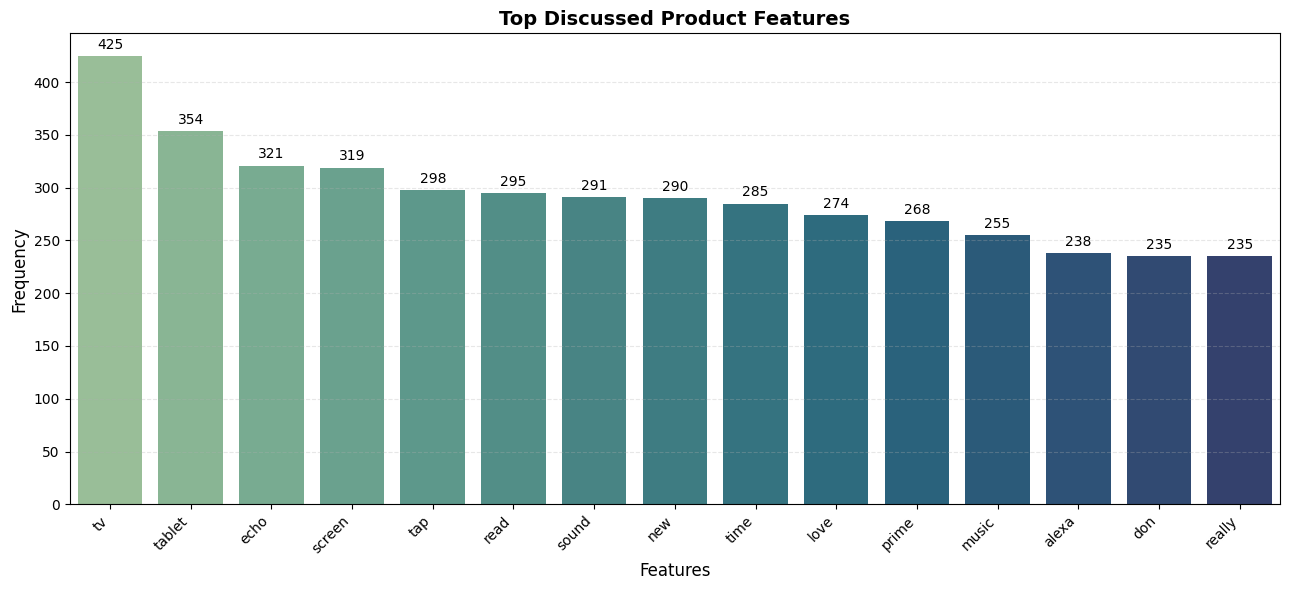

In [30]:
# Bar Chart Visualization

plt.figure(figsize=(13,6))

ax = sns.barplot(
    x="Feature",
    y="Frequency",
    data=feature_df.head(15),
    palette="crest"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Top Discussed Product Features", fontsize=14, weight='bold')
plt.xlabel("Features", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

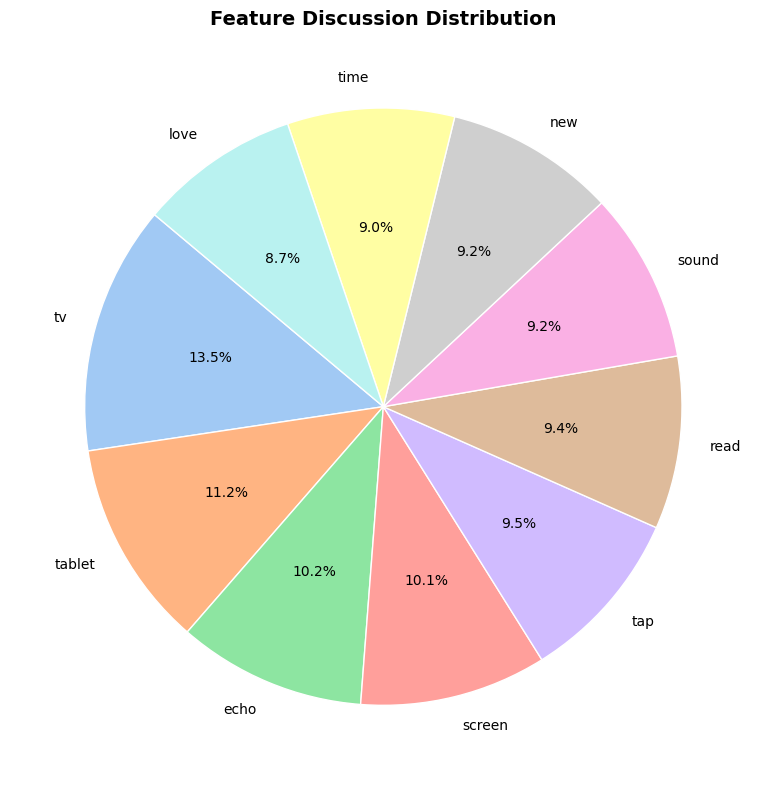

In [31]:
# Pie Chart Visualization

colors = sns.color_palette("pastel")

plt.figure(figsize=(8,8))

plt.pie(
    feature_df["Frequency"].head(10),
    labels=feature_df["Feature"].head(10),
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops={"edgecolor": "white"}
)

plt.title("Feature Discussion Distribution", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

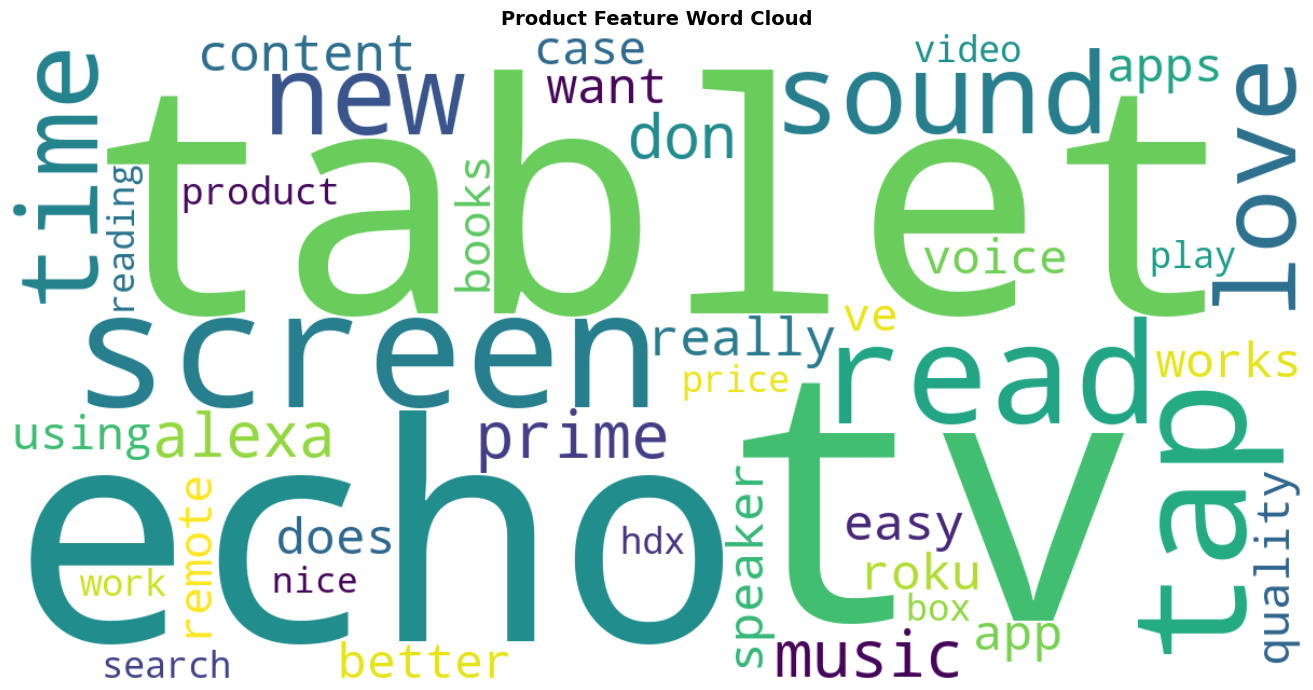

In [32]:
# Word Cloud Visualization

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis"
).generate_from_frequencies(
    dict(zip(feature_df["Feature"], feature_df["Frequency"]))
)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Product Feature Word Cloud", fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

In [34]:
# Summary of Findings

top_features = feature_df.head(5)["Feature"].tolist()

print("Based on the analysis, the most frequently discussed product features are:")
print(", ".join(top_features))

Based on the analysis, the most frequently discussed product features are:
tv, tablet, echo, screen, tap
